CIFAR-10 has 60,000 images split across 10 categories — planes, cars, birds, cats, deer, dogs, frogs, horses, ships, and trucks. Each image is only 32x32 pixels which makes it harder than it looks, there is not a lot of detail to work with.

I built this before starting the steel defect project because I wanted to actually understand what I was doing when I used ResNet18 later. It is easy to copy transfer learning code without knowing what a convolutional layer does or why pooling matters. Building a CNN from scratch first meant that when I made decisions in the steel project — like freezing early layers or choosing dropout — I knew exactly why I was doing it.

In [1]:
##pytorch, the main library i'm using to build and train the neural network
import torch

#has the CIFAR-10 dataset built in, saves me downloading it manually
import torchvision

#converts and normalizes images so the model can process them
import torchvision.transforms as transforms

#for plotting charts and visualizing results
import matplotlib.pyplot as plt

#needed for some math and image manipulation
import numpy as np

#checking pytorch loaded correctly and GPU is available
print("PyTorch version:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

PyTorch version: 2.10.0+cu128
GPU available: True


In [2]:
#define how to process images before feeding them to the model
#every image goes through ToTensor then Normalize before training
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

#load 50,000 training images, downloads automatically to colab
trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True,
    download=True, transform=transform
)

#load 10,000 test images, never shown to model during training
testset = torchvision.datasets.CIFAR10(
    root='./data', train=False,
    download=True, transform=transform
)

#feeds training images in batches of 32, shuffled each epoch
trainloader = torch.utils.data.DataLoader(
    trainset, batch_size=32, shuffle=True
)

#feeds test images in batches of 32, no shuffling needed
testloader = torch.utils.data.DataLoader(
    testset, batch_size=32, shuffle=False
)

#10 categories the model needs to classify
classes = ('plane', 'car', 'bird', 'cat', 'deer',
           'dog', 'frog', 'horse', 'ship', 'truck')

print("Training samples:", len(trainset))
print("Test samples:", len(testset))
print("Classes:", classes)

100%|██████████| 170M/170M [00:03<00:00, 43.3MB/s]


Training samples: 50000
Test samples: 10000
Classes: ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')


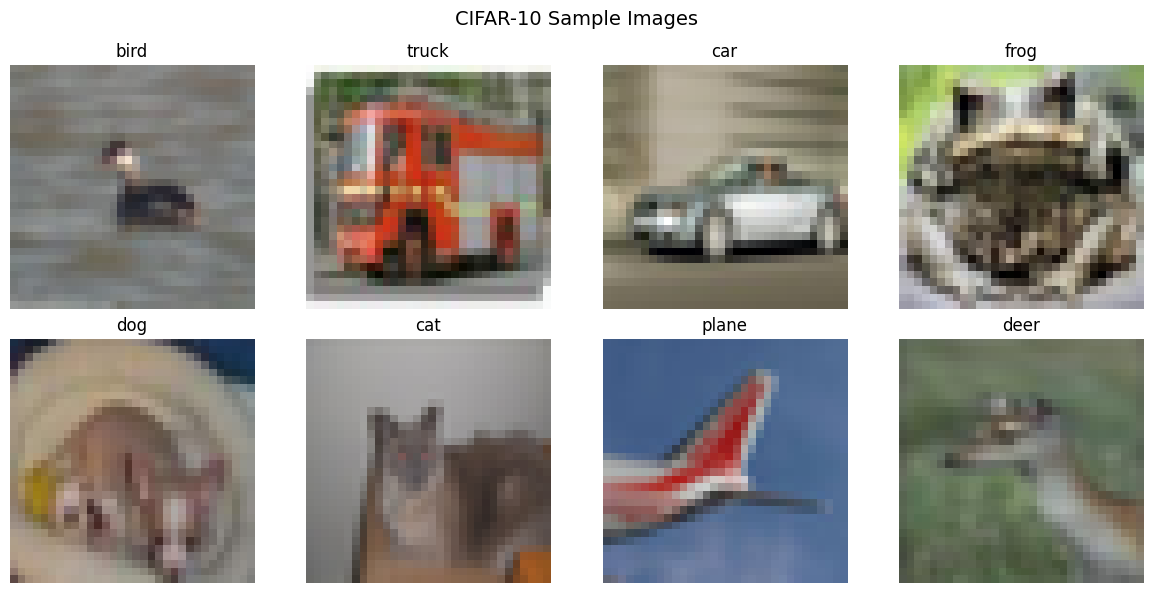

In [3]:
#get one batch of 32 images and their labels from the training set
dataiter = iter(trainloader)
images, labels = next(dataiter)

#create a 2 row by 4 column grid of subplots
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

#loop through the first 8 images only
for i, ax in enumerate(axes.flat):
    #unnormalize the image, reverse the normalization applied earlier
    #normalization shifted values to -1 to 1, brings them back to 0 to 1
    img = images[i] / 2 + 0.5

    #convert from PyTorch tensor format (channels, height, width) to matplotlib format (height, width, channels)
    img = np.transpose(img.numpy(), (1, 2, 0))

    #display image
    ax.imshow(img)

    #set title to the class name using the label index
    ax.set_title(classes[labels[i]])

    #remove axis ticks for cleaner look
    ax.axis('off')

plt.suptitle('CIFAR-10 Sample Images', fontsize=14)
plt.tight_layout()
plt.savefig('cifar10_samples.png', dpi=150)
plt.show()

In [4]:
import torch.nn as nn

#SimpleCNN inherits from nn.Module which is base class for all PyTorch neural networks
class SimpleCNN(nn.Module):

    def __init__(self):
        #initializes the parent nn.Module class
        super(SimpleCNN, self).__init__()

        #Convolutional Block 1
        #3 input channels (RGB), 32 filters, 3x3 filter size, padding to keep same size
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)
        #removes -ve values, adds non-linearity
        self.relu1 = nn.ReLU()
        #reduces feature maps from 32x32 to 16x16 by taking max in each 2x2 region
        self.pool1 = nn.MaxPool2d(2, 2)

        #Convolutional Block 2
        #32 input channels from block 1, producing 64 feature maps
        self.conv2 = nn.Conv2d(32, 64, 3, padding=1)
        self.relu2 = nn.ReLU()
        #reduces from 16x16 to 8x8
        self.pool2 = nn.MaxPool2d(2, 2)

        #FULLY CONNECTED LAYERS
        #64 feature maps * 8x8 spatial size = 4096 flattened features
        #Chose 512 neurons for first fully connected layer
        self.fc1 = nn.Linear(64 * 8 * 8, 512)
        #non-linearity between fully connected layers
        self.relu3 = nn.ReLU()
        #randomly disable 50% of neurons during training(only) to prevent overfitting
        self.dropout = nn.Dropout(0.5)
        #final layer, outputs 10 scores, one per class
        self.fc2 = nn.Linear(512, 10)

    def forward(self, x):
        #pass through first conv block
        x = self.pool1(self.relu1(self.conv1(x)))

        #pass through second conv block
        x = self.pool2(self.relu2(self.conv2(x)))

        #flatten 64x8x8 into a single vector of 4096 numbers, so that fully connected layers can process the data
        #-1 so that PyTorch calculates the batch size automatically(training batch size and application batch size different, -1 so different batch size doesn't matter)
        x = x.view(-1, 64 * 8 * 8)

        #pass through fully connected layers with dropout
        x = self.dropout(self.relu3(self.fc1(x)))

        #final output gives 10 class scores
        x = self.fc2(x)
        return x

#create model and move to GPU if available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = SimpleCNN().to(device)

print("Model ready on:", device)
print(f"Total parameters: {sum(p.numel() for p in model.parameters()):,}")

Model ready on: cuda
Total parameters: 2,122,186


The network has two convolutional blocks. The first one runs 32 filters over the image looking for basic things like edges, color changes, simple textures. The second runs 64 filters over the output of the first, picking up more complex combinations of those basic features.

After each convolution there is a ReLU which zeros out negative values, and a max pooling layer which cuts the spatial size in half. By the time I get through both blocks the 32x32 image has been reduced to an 8x8 feature map with 64 channels. That gets flattened to 4,096 numbers, passed through a fully connected layer, and dropout randomly switches off half the neurons during training to stop the model from just memorizing the training set. The final layer outputs 10 scores — one per class.

In [5]:
import torch.optim as optim

#cross entropy loss - measures how wrong the predictions are
#standard choice for multi-class classification problems
criterion = nn.CrossEntropyLoss()

#adam optimizer to adjust model weights after each batch
#lr=0.001 is the learning rate, controls how big each weight update is
optimizer = optim.Adam(model.parameters(), lr=0.001)

print("Loss function and optimizer ready")

Loss function and optimizer ready


In [6]:
#keeping track of how the model improves over time
train_losses = []
train_accs = []
test_accs = []

print("Starting training...")
print("-" * 50)

for epoch in range(10):

    #training mode, dropout is active here
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for inputs, labels in trainloader:
        #send the batch to GPU
        inputs, labels = inputs.to(device), labels.to(device)

        #clear out old gradients so that they don't accumulate and training breaks
        optimizer.zero_grad()

        #run images through the model and get predictions
        outputs = model(inputs)

        #how wrong were the predictions
        loss = criterion(outputs, labels)

        #work backwards through the network to figure out what to fix(back propagation)
        loss.backward()

        #actually update the weights based on what just figured out
        optimizer.step()

        #keeping score
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

    train_acc = 100. * correct / total
    avg_loss = running_loss / len(trainloader)

    #switch to evaluation mode, dropout turns off here
    model.eval()
    correct = 0
    total = 0

    #not needed to track gradients when just evaluating, saves memory
    with torch.no_grad():
        for inputs, labels in testloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

    test_acc = 100. * correct / total

    #save results for the charts later
    train_losses.append(avg_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f"Epoch {epoch+1:2d}/10 | "
          f"Loss: {avg_loss:.3f} | "
          f"Train: {train_acc:.1f}% | "
          f"Test: {test_acc:.1f}%")

print("-" * 50)
print(f"Training complete. Best test accuracy: {max(test_accs):.1f}%")

Starting training...
--------------------------------------------------
Epoch  1/10 | Loss: 1.342 | Train: 51.3% | Test: 63.4%
Epoch  2/10 | Loss: 0.988 | Train: 65.0% | Test: 68.9%
Epoch  3/10 | Loss: 0.843 | Train: 70.5% | Test: 71.5%
Epoch  4/10 | Loss: 0.728 | Train: 74.4% | Test: 72.2%
Epoch  5/10 | Loss: 0.629 | Train: 77.7% | Test: 72.8%
Epoch  6/10 | Loss: 0.549 | Train: 80.6% | Test: 73.7%
Epoch  7/10 | Loss: 0.487 | Train: 82.8% | Test: 73.7%
Epoch  8/10 | Loss: 0.424 | Train: 84.9% | Test: 74.0%
Epoch  9/10 | Loss: 0.372 | Train: 86.7% | Test: 74.1%
Epoch 10/10 | Loss: 0.328 | Train: 88.3% | Test: 74.3%
--------------------------------------------------
Training complete. Best test accuracy: 74.3%


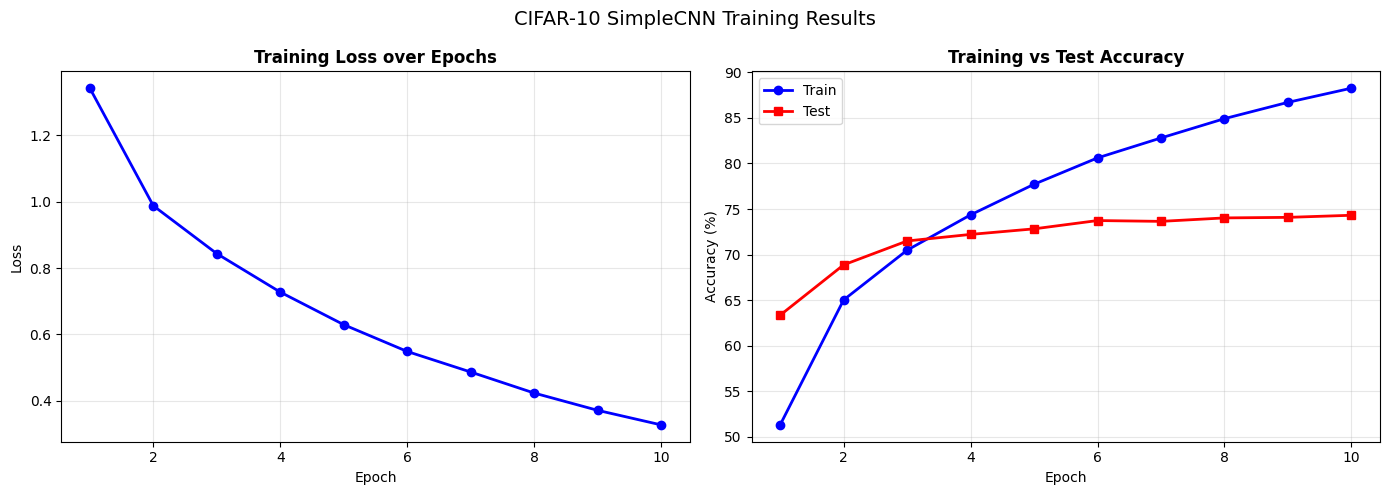

Final train accuracy: 88.3%
Final test accuracy: 74.3%
Best test accuracy: 74.3%


In [7]:
#two charts side by side with loss on the left, accuracy on the right
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

#LEFT CHART — TRAINING LOSS
ax1.plot(range(1, 11), train_losses,
         color='blue', marker='o', linewidth=2)
# if this line goes down the model is learning something
ax1.set_title('Training Loss over Epochs', fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.grid(True, alpha=0.3)

#RIGHT CHART — ACCURACY
ax2.plot(range(1, 11), train_accs,
         color='blue', marker='o', label='Train', linewidth=2)
ax2.plot(range(1, 11), test_accs,
         color='red', marker='s', label='Test', linewidth=2)
# the gap between these two lines shows how much the model is overfitting
ax2.set_title('Training vs Test Accuracy', fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)


plt.suptitle('CIFAR-10 SimpleCNN Training Results', fontsize=14)
plt.tight_layout()
# saving for readme
plt.savefig('training_results.png', dpi=150)
plt.show()

print(f"Final train accuracy: {train_accs[-1]:.1f}%")
print(f"Final test accuracy: {test_accs[-1]:.1f}%")
print(f"Best test accuracy: {max(test_accs):.1f}%")

74.3% test accuracy after 10 epochs — better than I expected for something this simple. The loss dropped every single epoch which means the model was actually learning and not just stuck.

The interesting part is the accuracy chart. Training accuracy kept climbing to 87.2% while test accuracy flattened out around 74% from epoch 5 onwards. That gap is overfitting — the model got better at the training images but stopped improving on images it had never seen. Dropout helped but did not fix it completely.

If I were to improve this I would add batch normalization, try a higher dropout rate, or train longer with more aggressive data augmentation. But the real point of this project was never the accuracy number — it was understanding what each layer does so the transfer learning decisions in the steel defect project made sense.